In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import h5py
from collections import Counter
import scipy.sparse as sp
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patheffects as path_effects
from matplotlib_venn import venn3
import pyranges as pr
import yaml
import time
from itertools import combinations
import gget

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

import scvi
from scvi.external import SysVI

import cupy as cp
import cudf
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
%%time 
# === Load and filter GTF ===
gtf_file = "/nfs/turbo/umms-indikar/shared/projects/reference_genome/prebuilt/refdata-gex-GRCh38-2024-A/genes/genes.gtf"
gtf = pr.read_gtf(gtf_file)

exons = gtf[gtf.Feature == "exon"].df
print(f"{exons.shape=}")
exons.head()


exons.shape=(1586950, 27)
CPU times: user 51.3 s, sys: 4.42 s, total: 55.7 s
Wall time: 55.9 s


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
0,GL000009.2,ENSEMBL,exon,56139,58376,.,-,.,ENSG00000278704,1,...,ENST00000618686,NA,NaN,1,ENSE00003753029,1,NaN,NaN,ENSP00000484918.1,NaN
1,GL000194.1,ENSEMBL,exon,114985,115018,.,-,.,ENSG00000277400,1,...,ENST00000613230,1,NaN,1,ENSE00002299440,2,NaN,NaN,ENSP00000483280.1,NaN
2,GL000194.1,ENSEMBL,exon,112791,112850,.,-,.,ENSG00000277400,1,...,ENST00000613230,1,NaN,2,ENSE00003739295,1,NaN,NaN,ENSP00000483280.1,NaN
3,GL000194.1,ENSEMBL,exon,53589,55676,.,-,.,ENSG00000277400,1,...,ENST00000613230,1,NaN,3,ENSE00003723764,1,NaN,NaN,ENSP00000483280.1,NaN
4,GL000194.1,ENSEMBL,exon,114985,115055,.,-,.,ENSG00000274847,1,...,MAFIP-201,1,NaN,1,ENSE00003736481,1,HGNC:31102,NaN,ENSP00000478910.1,NaN


In [3]:
fpath = "../../resources/isoform_map.csv.gz"

idf = pd.read_csv(fpath)
print(f"{idf.shape=}")

idf['uniprot'] = np.where(idf['UniProtKB/TrEMBL ID'].isna(), idf['UniProtKB/Swiss-Prot ID'], idf['UniProtKB/TrEMBL ID'])

transcript_2_uniprot = dict(zip(idf['Transcript name'].values, idf['uniprot'].values))

idf.head()

idf.shape=(110149, 11)


,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Protein stable ID,Protein stable ID version,Transcript length (including UTRs and CDS),Transcript name,Gene name,UniProtKB/Swiss-Prot ID,UniProtKB/TrEMBL ID,uniprot
0,ENSG00000198888,ENSG00000198888.2,ENST00000361390,ENST00000361390.2,ENSP00000354687,ENSP00000354687.2,956,MT-ND1-201,MT-ND1,P03886,U5Z754,U5Z754
1,ENSG00000198763,ENSG00000198763.3,ENST00000361453,ENST00000361453.3,ENSP00000355046,ENSP00000355046.4,1042,MT-ND2-201,MT-ND2,P03891,Q7GXY9,Q7GXY9
2,ENSG00000198804,ENSG00000198804.2,ENST00000361624,ENST00000361624.2,ENSP00000354499,ENSP00000354499.2,1542,MT-CO1-201,MT-CO1,P00395,U5YWV7,U5YWV7
3,ENSG00000198712,ENSG00000198712.1,ENST00000361739,ENST00000361739.1,ENSP00000354876,ENSP00000354876.1,684,MT-CO2-201,MT-CO2,P00403,U5Z487,U5Z487
4,ENSG00000228253,ENSG00000228253.1,ENST00000361851,ENST00000361851.1,ENSP00000355265,ENSP00000355265.1,207,MT-ATP8-201,MT-ATP8,P03928,U5YV54,U5YV54


In [4]:
fpath = "../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:10]

['ZNF354C',
 'KLF12',
 'ZNF143',
 'ZIC2',
 'ZNF274',
 'SP2',
 'ZBTB7A',
 'BCL6B',
 'ZBTB49',
 'ZIC1']

In [5]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/isoforms.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 290 ms, sys: 429 ms, total: 719 ms
Wall time: 1.27 s


AnnData object with n_obs × n_vars = 21062 × 113335
    obs: 'dataset', 'dataset_bdata', 'source', 'cluster', 'group', 'label', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id'
    uns: 'subgroup_colors'
    obsm: 'X_umap'

In [6]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.filter_genes(adata, min_counts=30)

adata.layers['counts'] = adata.X.copy()

rsc.pp.normalize_total(adata, target_sum=1e4)
rsc.pp.log1p(adata)

adata.layers['log_norm'] = adata.X.copy()
adata

filtered out 43826 genes that are detected in less than 30 counts


AnnData object with n_obs × n_vars = 21062 × 69509
    obs: 'dataset', 'dataset_bdata', 'source', 'cluster', 'group', 'label', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'n_counts', 'n_cells'
    uns: 'subgroup_colors', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', 'log_norm'

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:33)


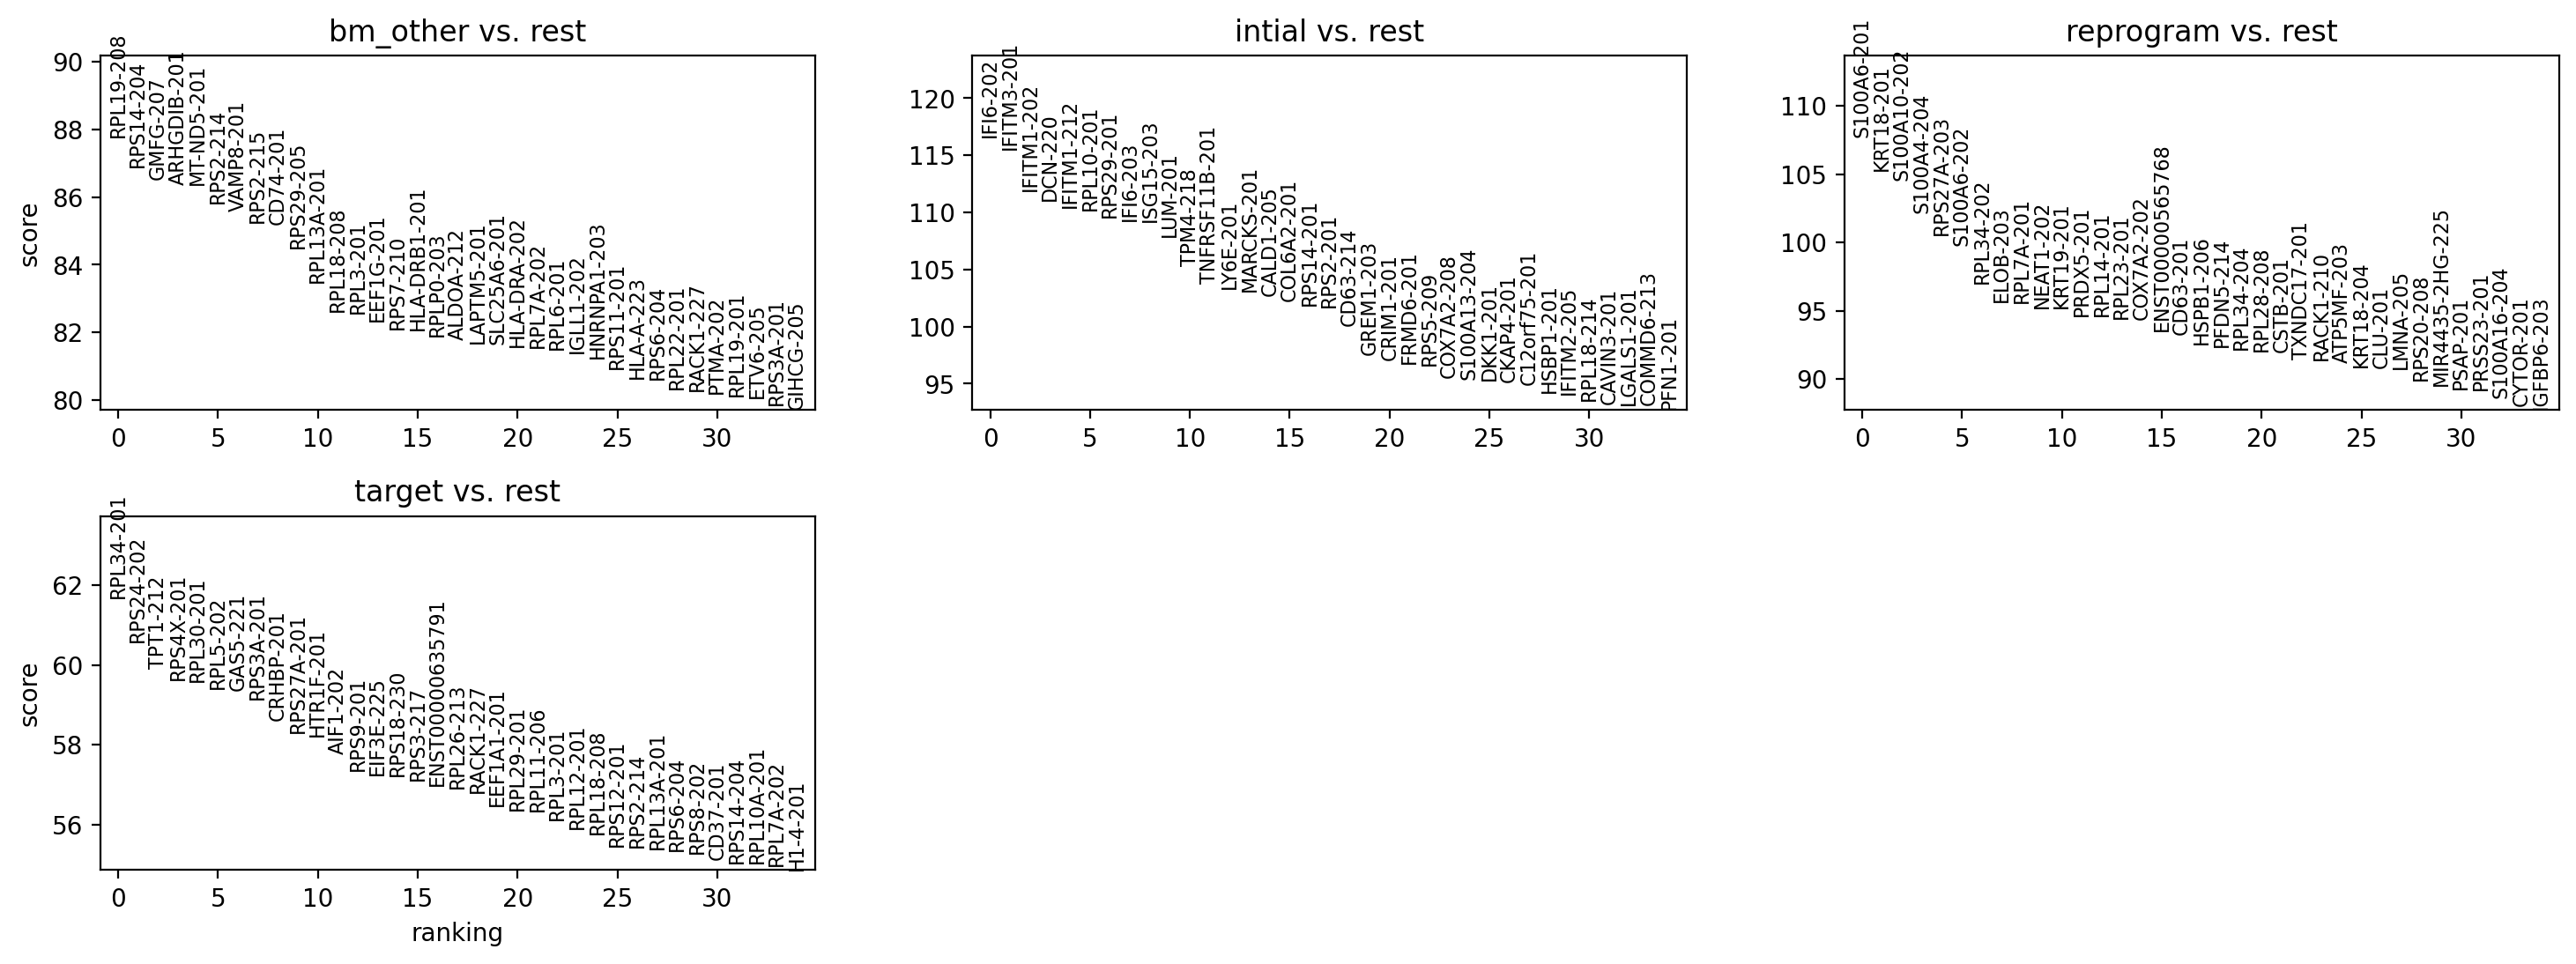

CPU times: user 1min 25s, sys: 1min 1s, total: 2min 26s
Wall time: 35.1 s


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,bm_other,RPL19-208,87.760811,5.114663,0.0,0.0,0.983300,0.159790
1,bm_other,RPS14-204,86.878601,7.402966,0.0,0.0,0.995445,0.094857
2,bm_other,GMFG-207,86.528618,5.072167,0.0,0.0,0.973178,0.087025
3,bm_other,ARHGDIB-201,86.367561,5.231786,0.0,0.0,0.976468,0.106838
4,bm_other,MT-ND5-201,86.367462,2.583083,0.0,0.0,0.999241,0.848627


In [7]:
%%time
rsc.get.anndata_to_CPU(adata)
sc.tl.rank_genes_groups(
    adata, 
    groupby='group',
    method='wilcoxon',
    use_raw=False,
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    pval_cutoff=0.05,
    log2fc_min=1.0,
    log2fc_max=10.0,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 3
sc.pl.rank_genes_groups(
    adata,
    n_genes=35,
    sharey=False,
    ncols=3,
)

deg.head()

In [9]:
# parameters
pct_group_quantile = 0.80    # top 10% by pct_nz_group
pct_ref_quantile   = 0.25    # bottom 10% by pct_nz_reference
top_n_genes        = 50

# 1. compute per‑group thresholds
thresholds = deg.groupby('group').agg(
    group_threshold=('pct_nz_group',   lambda x: x.quantile(pct_group_quantile)),
    reference_threshold=('pct_nz_reference', lambda x: x.quantile(pct_ref_quantile))
)

# 2. merge thresholds back into deg
deg_filtered = deg.merge(thresholds, on='group')

# 3. filter by percentile criteria
deg_filtered = deg_filtered[
    (deg_filtered['pct_nz_group']     >= deg_filtered['group_threshold']) &
    (deg_filtered['pct_nz_reference'] <= deg_filtered['reference_threshold'])
]

# 4. sort within each group: log‐FC ↓, pct_nz_group ↓, pct_nz_reference ↑
deg_sorted = deg_filtered.sort_values(
    by=['group','logfoldchanges','pct_nz_group','pct_nz_reference'],
    ascending=[True, False, False, True],
)

# 5. take top N per group
top_genes = deg_sorted.groupby('group').head(top_n_genes)

# 6. keep gene names and metrics
result = top_genes[
    ['group','names','logfoldchanges',
     'pct_nz_group','pct_nz_reference'],
]

print(result.to_string(index=False))

    group           names  logfoldchanges  pct_nz_group  pct_nz_reference
 bm_other      RNASE2-201        9.696671      0.288968          0.000994
 bm_other      VPREB1-202        9.429795      0.407389          0.002396
 bm_other      SUCNR1-201        8.610816      0.187753          0.000409
 bm_other       IGLL1-201        8.085269      0.242915          0.000994
 bm_other       PTPRC-209        7.330035      0.283907          0.002279
 bm_other        NKG7-201        7.020221      0.284666          0.002513
 bm_other        FUT7-201        6.408739      0.203947          0.002221
 bm_other       SPNS3-201        6.233913      0.289221          0.003682
 bm_other    ARHGEF18-206        6.221690      0.225455          0.002805
 bm_other        CST7-201        6.174460      0.203441          0.004208
 bm_other       CEBPA-201        6.170150      0.209514          0.003098
 bm_other       PDE3B-201        5.701006      0.236589          0.004500
   intial       HLA-A-204        8.530